In [1]:
import sys, pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize

from procs.stochastic_processes import (
    MarketReplayMidpriceModel, PoissonArrivalModel, ExponentialFillFunction,
)
from procs.gym.model_dynamics import LimitOrderModelDynamics
from procs.gym.trading_environment import TradingEnvironment
from procs.gym.sb3_wrapper import StableBaselinesTradingEnvironment
from procs.rewards import PnLReward, CjMmDrawdownPenalty
from procs.agents import AvellanedaStoikovAgent, Sb3Agent
from procs.gym.helpers.plotting import plot_trajectory, plot_learned_policy
from procs.gym.helpers.generate_trajectory_stats import generate_trajectory_stats
from procs.gym.helpers.fast_rollout import fast_simulate
from procs.gym.data_loader import load_single_day
from procs.gym.calibration import tune_gamma, calibrate_as_parameters
from procs.gym.features import FeatureComputer, RollingVolatility
from procs.gym.reward_scale import estimate_reward_scale

%matplotlib inline


In [2]:
DATA_PATH = r"C:\Users\john-\Documents\Thesis_AI4T\datasets\binance_book_snapshot_25_2025-01-01_DOGEUSDT.csv"
S, dt_sec, dt_index = load_single_day(DATA_PATH)
T_sec = float(dt_sec.sum())
sigma = MarketReplayMidpriceModel(S, dt_sec).volatility
print(f"Loaded {len(S):,} snapshots, σ={sigma:.6f}, T={T_sec:.0f}s")

Loaded 713,815 snapshots, σ=0.000021, T=86398s


Loaded 713,815 snapshots over 24.00 hours
Detected 52,493 market order arrivals (0.61/sec average)


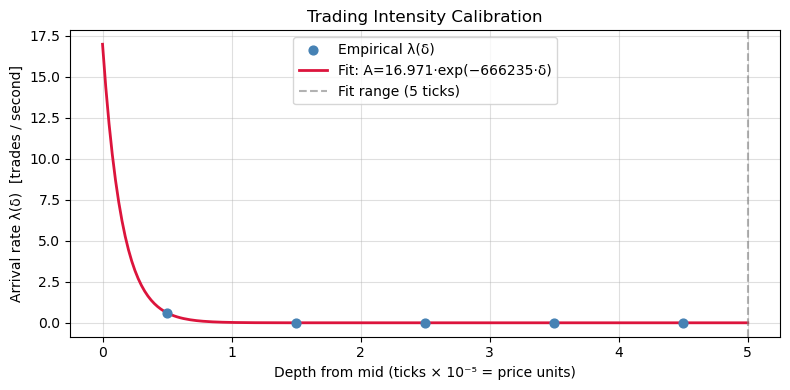


── Calibrated A-S Parameters ──────────────────────
  σ     = 0.000020  (price / √s)
  A     = 16.9709   (trades / s at zero depth)
  κ     = 666235  (1 / price unit)
  Fit range: δ ∈ [0, 0.00005] (5 tick levels)
  Bins used in regression: 2 / 5


In [3]:
params = calibrate_as_parameters(
    filepath=DATA_PATH,
    tick_size=0.00001,
    fit_depth_max=5 * 0.00001,   # first 5 tick levels — near-mid range
    plot=True,
)

# Unpack directly into your existing variable names
sigma, A, kappa = params.sigma, params.A, params.kappa

In [16]:
tick, Q_MAX, phi = 0.00001, 50, 0.01
alpha_dd = 1.0   # drawdown penalty weight (sweep later)

# Calibrate γ
best_gamma, study = tune_gamma(
    midprices=S, dt_array=dt_sec,
    sigma=sigma, kappa=kappa, A=A,
    tick_size=tick, Q_MAX=Q_MAX,
    gamma_range=(0.001, 1.0),
    n_trials=20, num_trajectories=20,
)
print(f"Using γ = {best_gamma:.6f}")

reward_scale = estimate_reward_scale(
    midprices=S, dt_array=dt_sec, sigma=sigma,
    kappa=kappa, A=A, terminal_time=T_sec,
    tick_size=tick, Q_MAX=Q_MAX,
    num_trajectories=50, use_bm=False,
)
print(f"Reward scale: {reward_scale:.4f}")

[I 2026-04-09 14:19:51,409] A new study created in memory with name: no-name-97905a14-a6aa-4980-bcc5-bcf3caa33f21
[I 2026-04-09 14:20:13,702] Trial 0 finished with value: 0.0027759874887755115 and parameters: {'gamma': 0.016818746089387927}. Best is trial 0 with value: 0.0027759874887755115.
[I 2026-04-09 14:20:35,715] Trial 1 finished with value: 0.0016299578379872768 and parameters: {'gamma': 0.0019047388877253585}. Best is trial 0 with value: 0.0027759874887755115.
[I 2026-04-09 14:20:57,879] Trial 2 finished with value: 0.002583383706441084 and parameters: {'gamma': 0.014332408583439538}. Best is trial 0 with value: 0.0027759874887755115.
[I 2026-04-09 14:21:19,903] Trial 3 finished with value: 0.009783968298287144 and parameters: {'gamma': 0.2354472115554372}. Best is trial 3 with value: 0.009783968298287144.
[I 2026-04-09 14:21:41,968] Trial 4 finished with value: 0.0016297222739479415 and parameters: {'gamma': 0.002116020462549176}. Best is trial 3 with value: 0.0097839682982871


Best γ = 0.235447
Best sharpe = 0.009784
Using γ = 0.235447
Reward scale: 3.3581


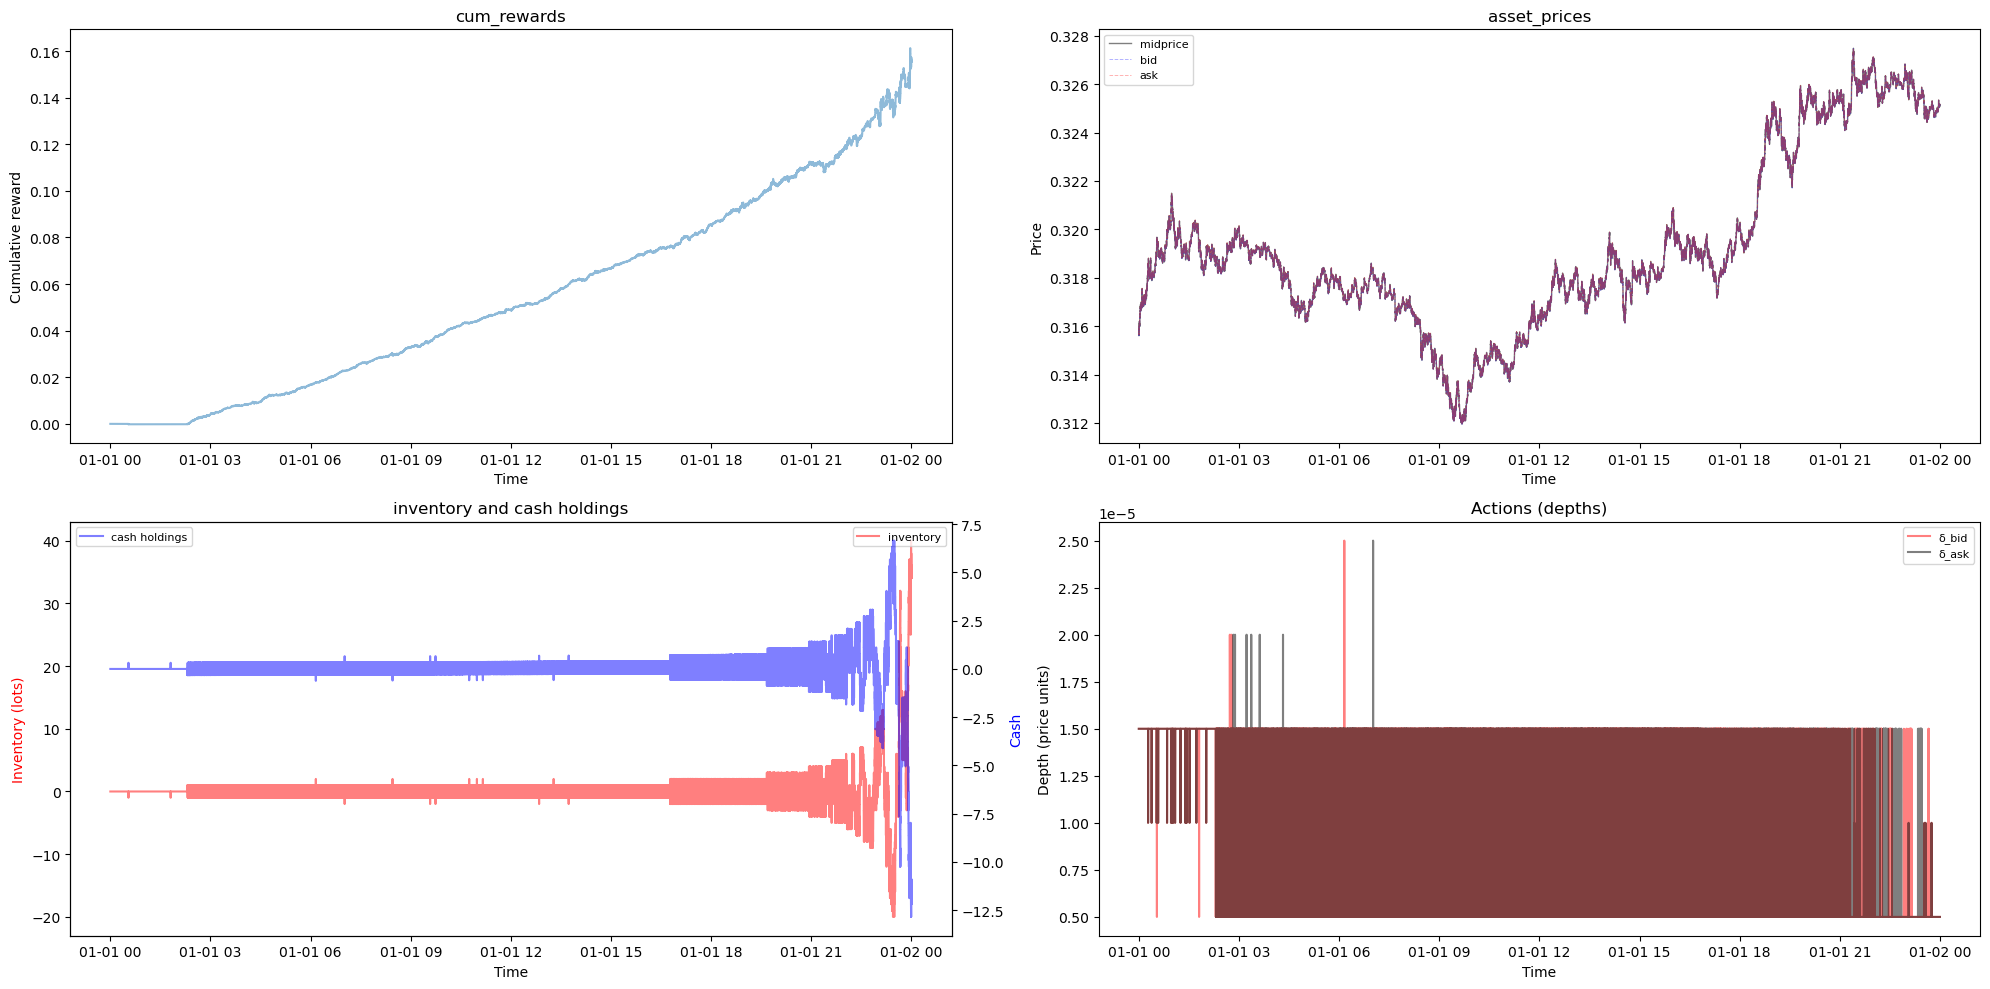

A-S Sharpe: 0.0091
A-S Max DD: 0.0121
A-S PnL:    0.0846


In [17]:
as_agent = AvellanedaStoikovAgent(best_gamma, sigma, kappa, T_sec, tick)

# Single trajectory with timestamps
env_as = TradingEnvironment(
    model_dynamics=LimitOrderModelDynamics(
        midprice_model=MarketReplayMidpriceModel(S, dt_sec, 1),
        arrival_model=PoissonArrivalModel(np.array([A, A]), 1, use_linear_approximation=False),
        fill_probability_model=ExponentialFillFunction(kappa, 1),
    ),
    reward_function=PnLReward(), max_inventory=Q_MAX,
)
plot_trajectory(env_as, as_agent, seed=42, datetime_index=dt_index)

# Metrics
as_stats = fast_simulate(
    midprices=S, dt_array=dt_sec, gamma=0.419, sigma=sigma,
    kappa=kappa, A=A, terminal_time=T_sec, tick_size=tick, Q_MAX=Q_MAX,
    num_trajectories=50, seed=42, use_linear_approximation=False,
)
print(f"A-S Sharpe: {as_stats['sharpe'].mean():.4f}")
print(f"A-S Max DD: {as_stats['max_drawdown'].mean():.4f}")
print(f"A-S PnL:    {as_stats['total_pnl'].mean():.4f}")